# Day 016: The Determinant (Measuring scaling factors and spatial collapse)


## 1. Objective
> To compute the determinant of transformation matrices programmatically, using it as a diagnostic metric to understand how data space expands, compresses, reflects, or collapses entirely.

## 2. Mathematical Foundation
> The determinant, $\det(\mathbf{A})$, is a scalar value that measures the change in area (2D) or volume (3D) caused by a linear transformation.  
> * **Formula ($2 \times 2$):** $\det(\mathbf{A}) = (a \cdot d) - (b \cdot c)$  
> * **Interpretations:**  
>   * $|\det(\mathbf{A})|$ gives the exact scaling multiplier for the area/volume.  
>   * If $\det(\mathbf{A}) < 0$, the space has been reflected (like viewing the data in a mirror).  
>   * If $\det(\mathbf{A}) = 0$, the matrix is singular. Space has lost at least one dimension (e.g., 2D to 1D).


## 3. Real-World & AI Applications
> * **Geospatial Mapping (Map Scaling):** Suppose you are building a custom GPS UI to track a running route stretching from the Kathmandu Valley up toward Rasuwa. If your app zooms in on the map, it applies a scaling matrix to the coordinates. The determinant of that matrix instantly tells the rendering engine exactly how much the geographical bounding box area has expanded on the screen, allowing it to dynamically adjust pixel resolutions. If a bug causes the determinant to hit 0, the entire map collapses into a single line of pixels—a fatal UI crash.  
> 
> * **AI/ML Use Case (Probability Density):** In advanced generative AI (like Normalizing Flows), we transform simple probability distributions (like a standard bell curve) into complex ones. The determinant tells the neural network exactly how the probability "volume" stretches and compresses, ensuring that the total probability always equals 100%.

## 4. Algorithmic Strategy
> * **NumPy Usage:** Use `np.linalg.det(A)`.   
> * **Floating Point Warnings:** Because computers use floating-point math, a determinant that should be exactly `0` might compute as `1.3e-16`. When checking for singular matrices in code, always use a tolerance check (e.g., `if abs(det) < 1e-9:`) instead of strict equality (`if det == 0:`).

## 5. Implementation

In [4]:
import numpy as np

def analyze_transformation(matrix_name, A):
    """Calculate and interprets the determinant of a 2x2 matrix."""
    det = np.linalg.det(A)
    
    print(f"--- Matrix: {matrix_name} ---")
    print(A)
    print(f"Determinant: {det:.4f}")
    
    # Interpretation logic with floating-point safety.
    if abs(det)<1e-9:
        print("Status: SPATIAL COLLAPSE (Singular Matrix). Dimension lost. Area is 0.")
    elif det < 0: 
        print(f"Status: REFLECTION. Space is flipped. Area scales by {abs(det):.4f}")
    elif abs(det - 1.0) < 1e-9:
        print("Status: AREA PRESERVED. The shape morphed but kept its original size.")
    else:
        print(f"Status: SCALED. Total area is multiplied by {det:.4f}")
    
    print("\n")

# i. Pure Rotation (90 degrees)
R = np.array([[ 0, -1],
              [ 1,  0]])
analyze_transformation("Rotation", R)

# ii. Scaling Matrix (Stretch x by 3, y by 2)
S = np.array([[ 3,  0],
              [ 0,  2]])
analyze_transformation("Scaling (3x2)", S)

# iii. Reflection Matrix (Flip across Y-axis)
Ref = np.array([[-1,  0],
                [ 0,  1]])
analyze_transformation("Reflection", Ref)

# iv. Singular Matrix (Redundant columns)
Singular = np.array([[ 2,  4],
                     [ 1,  2]])
analyze_transformation("Singular", Singular)


--- Matrix: Rotation ---
[[ 0 -1]
 [ 1  0]]
Determinant: 1.0000
Status: AREA PRESERVED. The shape morphed but kept its original size.


--- Matrix: Scaling (3x2) ---
[[3 0]
 [0 2]]
Determinant: 6.0000
Status: SCALED. Total area is multiplied by 6.0000


--- Matrix: Reflection ---
[[-1  0]
 [ 0  1]]
Determinant: -1.0000
Status: REFLECTION. Space is flipped. Area scales by 1.0000


--- Matrix: Singular ---
[[2 4]
 [1 2]]
Determinant: 0.0000
Status: SPATIAL COLLAPSE (Singular Matrix). Dimension lost. Area is 0.




## 6. Verification

In [5]:
print("--- Verification: Does Area truly scale by det(A)? ---")
# A simple 2x2 square: width = 2, height = 2 -> Area = 4
initial_area = 4.0

# Apply a shear and scale matrix
Transform = np.array([[2, 1],
                      [0, 3]])
det_T = np.linalg.det(Transform)

expected_new_area = initial_area * det_T
print(f"Initial Area: {initial_area}")
print(f"Determinant of Transform: {det_T:.2f}")
print(f"Mathematically Expected New Area: {expected_new_area:.2f}")

--- Verification: Does Area truly scale by det(A)? ---
Initial Area: 4.0
Determinant of Transform: 6.00
Mathematically Expected New Area: 24.00


### Visualization

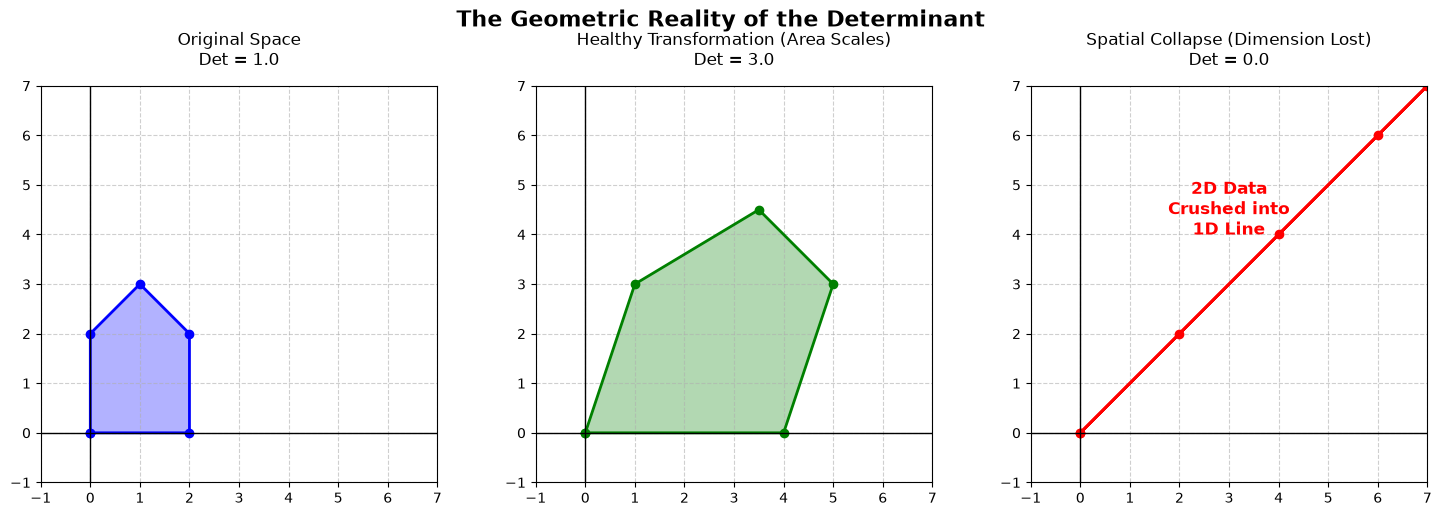

In [6]:
import matplotlib.pyplot as plt

# ==========================================
# Data Setup
# ==========================================

# Create a house shape to clearly see area and orientation
# Columns: [x], [y] coordinates
house = np.array([[0, 2, 2, 1, 0, 0],
                  [0, 0, 2, 3, 2, 0]])

# Matrix 1: A healthy transformation (Shear + Scale)
# det = (2*1.5) - (0.5*0) = 3. Area should triple.
Healthy_Matrix = np.array([[2, 0.5],
                           [0, 1.5]])

# Matrix 2: The Black Hole (Singular matrix)
# det = (1*2) - (2*1) = 0. Space collapses.
Singular_Matrix = np.array([[1, 2],
                            [1, 2]])

transformed_healthy = Healthy_Matrix @ house
transformed_collapsed = Singular_Matrix @ house

# ==========================================
# Plotting
# ==========================================

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("The Geometric Reality of the Determinant", fontsize=16, weight='bold')

def plot_shape(ax, data, title, color, det_val):
    ax.plot(data[0, :], data[1, :], color=color, linewidth=2, marker='o')
    ax.fill(data[0, :], data[1, :], color=color, alpha=0.3)
    ax.set_title(f"{title}\nDet = {det_val:.1f}", pad=15)
    
    ax.set_xlim(-1, 7)
    ax.set_ylim(-1, 7)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_aspect('equal')

# 1. Original
plot_shape(axs[0], house, "Original Space", 'blue', 1.0)

# 2. Healthy Transformation (Area stretches)
det_H = np.linalg.det(Healthy_Matrix)
plot_shape(axs[1], transformed_healthy, "Healthy Transformation (Area Scales)", 'green', det_H)

# 3. Spatial Collapse (Area becomes 0)
det_S = np.linalg.det(Singular_Matrix)
plot_shape(axs[2], transformed_collapsed, "Spatial Collapse (Dimension Lost)", 'red', det_S)

# Add a warning text to the collapsed plot
axs[2].text(3, 4, "2D Data\nCrushed into\n1D Line", color='red', 
            fontsize=12, weight='bold', ha='center')

plt.tight_layout()
plt.show()

## 7. Complexity Analysis
> - **Time Complexity:**  $\mathcal{O}(n^3)$ for $N \times N$ matrices in NumPy, which utilizes LAPACK routines (LU decomposition) under the hood.  
> - **Space Complexity:** $\mathcal{O}(n^2)$ temporary memory used during the factorization process.
